In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [20]:
from sklearn.model_selection import train_test_split
N = 200

X = torch.randn(N, 5)

y = torch.randn(N, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
#Scratch NN
import torch

# Initialize weights
w1 = torch.randn(5, 10, requires_grad=True)   # input → hidden1
b1 = torch.randn(10, requires_grad=True)

w2 = torch.randn(10, 6, requires_grad=True)   # hidden1 → hidden2
b2 = torch.randn(6, requires_grad=True)

w3 = torch.randn(6, 1, requires_grad=True)    # hidden2 → output
b3 = torch.randn(1, requires_grad=True)

def relu(x):
    return torch.clamp(x, min=0)

# Forward pass
def forwardpass(X):

    h1 = relu(X @ w1 + b1)        # hidden layer 1
    h2 = relu(h1 @ w2 + b2)       # hidden layer 2
    y_hat = h2 @ w3 + b3          # output layer

    return y_hat

In [22]:
def MSEloss(y_true, y_pred):
    loss = torch.mean((y_true - y_pred) ** 2)
    return loss

In [23]:
learning_rate = 0.001
epochs = 100

loss_history = []

for epoch in range(epochs):
        # Forward pass
        prediction=forwardpass(X_train)  
        
        loss = MSEloss(y_train, prediction)
        
        loss.backward()
        
        # Update weights
        with torch.no_grad():
            w1 -= learning_rate * w1.grad
            b1 -= learning_rate * b1.grad
            w2 -= learning_rate * w2.grad
            b2 -= learning_rate * b2.grad
            w3 -= learning_rate * w3.grad
            b3 -= learning_rate * b3.grad
        
        # Reset gradients
        w1.grad.zero_()
        b1.grad.zero_()
        w2.grad.zero_()
        b2.grad.zero_()
        w3.grad.zero_()
        b3.grad.zero_()

       
        with torch.no_grad():
            y_pred=forwardpass(X_test) 
            test_mse=MSEloss(y_test, y_pred)
            loss_history.append(test_mse)
            
        print(f"Epoch {epoch} | Train MSE: {loss.item():.4f}")
                

Epoch 0 | Train MSE: 62.3238
Epoch 1 | Train MSE: 46.4534
Epoch 2 | Train MSE: 36.0067
Epoch 3 | Train MSE: 28.8454
Epoch 4 | Train MSE: 23.6801
Epoch 5 | Train MSE: 19.8420
Epoch 6 | Train MSE: 16.9394
Epoch 7 | Train MSE: 14.7061
Epoch 8 | Train MSE: 12.9737
Epoch 9 | Train MSE: 11.6046
Epoch 10 | Train MSE: 10.5115
Epoch 11 | Train MSE: 9.6385
Epoch 12 | Train MSE: 8.9263
Epoch 13 | Train MSE: 8.3473
Epoch 14 | Train MSE: 7.8622
Epoch 15 | Train MSE: 7.4559
Epoch 16 | Train MSE: 7.1134
Epoch 17 | Train MSE: 6.8225
Epoch 18 | Train MSE: 6.5736
Epoch 19 | Train MSE: 6.3590
Epoch 20 | Train MSE: 6.1728
Epoch 21 | Train MSE: 6.0099
Epoch 22 | Train MSE: 5.8662
Epoch 23 | Train MSE: 5.7388
Epoch 24 | Train MSE: 5.6249
Epoch 25 | Train MSE: 5.5225
Epoch 26 | Train MSE: 5.4296
Epoch 27 | Train MSE: 5.3448
Epoch 28 | Train MSE: 5.2669
Epoch 29 | Train MSE: 5.1948
Epoch 30 | Train MSE: 5.1279
Epoch 31 | Train MSE: 5.0652
Epoch 32 | Train MSE: 5.0063
Epoch 33 | Train MSE: 4.9507
Epoch 34 | Tr

Text(0, 0.5, 'MSE')

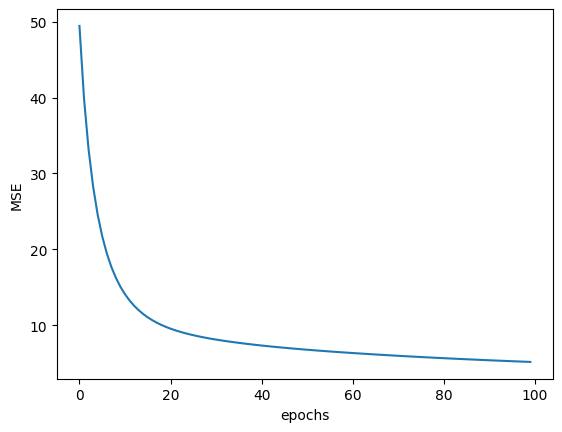

In [24]:
plt.plot(range(epochs),loss_history) 
plt.xlabel("epochs")
plt.ylabel("MSE") 

In [25]:
checkpoint = {
    "w1": w1.detach(),
    "b1": b1.detach(),
    "w2": w2.detach(),
    "b2": b2.detach(),
    "w3": w3.detach(),
    "b3": b3.detach(),
    "learning_rate": learning_rate,
    "epochs": epochs
}

torch.save(checkpoint, "Neural Network Sample")

In [26]:
checkpoint = torch.load("Neural Network Sample")

w1 = checkpoint["w1"]
b1 = checkpoint["b1"]
w2 = checkpoint["w2"]
b2 = checkpoint["b2"]
w3 = checkpoint["w3"]
b3 = checkpoint["b3"]

learning_rate = checkpoint["learning_rate"]
epochs = checkpoint["epochs"]

In [27]:
with torch.no_grad():
    y_pred = forwardpass(X_test)
    mse = MSEloss(y_test, y_pred)
print(f"Test MSE: {mse.item():.4f}")

Test MSE: 5.1512


In [29]:
#Alternatively w/torch: 
import torch
import torch.nn as nn
import torch.optim as optim
loss_history2=[]

# Define the network
model = nn.Sequential(
    nn.Linear(5, 10),
    nn.ReLU(),
    nn.Linear(10, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)


# Loss function
criterion = nn.MSELoss()  # Mean Squared Error

# Optimizer instead of gradient descent
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Forward pass
epochs = 100
for epoch in range(1, epochs + 1):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history2.append(loss.item())
    # Print loss
    print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.4f}")


Epoch [1/100], Loss: 1.1628
Epoch [2/100], Loss: 1.1590
Epoch [3/100], Loss: 1.1553
Epoch [4/100], Loss: 1.1517
Epoch [5/100], Loss: 1.1480
Epoch [6/100], Loss: 1.1444
Epoch [7/100], Loss: 1.1408
Epoch [8/100], Loss: 1.1373
Epoch [9/100], Loss: 1.1337
Epoch [10/100], Loss: 1.1303
Epoch [11/100], Loss: 1.1268
Epoch [12/100], Loss: 1.1234
Epoch [13/100], Loss: 1.1200
Epoch [14/100], Loss: 1.1167
Epoch [15/100], Loss: 1.1134
Epoch [16/100], Loss: 1.1101
Epoch [17/100], Loss: 1.1069
Epoch [18/100], Loss: 1.1038
Epoch [19/100], Loss: 1.1006
Epoch [20/100], Loss: 1.0975
Epoch [21/100], Loss: 1.0943
Epoch [22/100], Loss: 1.0912
Epoch [23/100], Loss: 1.0881
Epoch [24/100], Loss: 1.0851
Epoch [25/100], Loss: 1.0822
Epoch [26/100], Loss: 1.0792
Epoch [27/100], Loss: 1.0763
Epoch [28/100], Loss: 1.0735
Epoch [29/100], Loss: 1.0708
Epoch [30/100], Loss: 1.0681
Epoch [31/100], Loss: 1.0655
Epoch [32/100], Loss: 1.0629
Epoch [33/100], Loss: 1.0603
Epoch [34/100], Loss: 1.0578
Epoch [35/100], Loss: 1

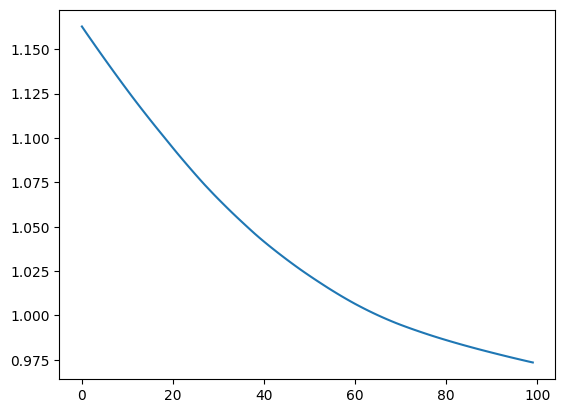

In [30]:
plt.plot(range(epoch), loss_history2)

In [33]:
torch.save(model, "nn_model.pth")

In [35]:
#use and evaluate model 
model = torch.load("nn_model.pth", weights_only=False)
model.eval()  # set to evaluation mode
with torch.no_grad():  # disables gradient computation for efficiency
    y_pred_test = model(X_test)

print(MSEloss(y_test, y_pred_test))

tensor(0.9562)


Perceptron: input ->sum function->activation-> output

In [40]:
X = torch.randn(200, 5)
y = torch.randint(0, 2, (200, 1), dtype=torch.float32)  # binary labels 0 or 1
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

weights = torch.randn(5, 1, requires_grad=True)
bias = torch.randn(1, requires_grad=True)

# 3. Set hyperparameters
learning_rate = 0.1
epochs = 100

for epoch in range(epochs):
    # Linear output
    linear_output = X_train @ weights + bias
    
    # Apply step function for perceptron (sign activation)
    predictions = (linear_output >= 0).float()
    
    loss = y_train - predictions
    
    # Perceptron weight update rule
    weights_grad = (X_train.T @ loss) / N
    bias_grad = loss.mean()
    
    # Update weights and bias
    with torch.no_grad():
        weights -= learning_rate * weights_grad
        bias -= learning_rate * bias_grad

# 5. Evaluate accuracy
with torch.no_grad():
    linear_output = X_train @ weights + bias
    predictions = (linear_output >= 0).float()
    accuracy = (predictions == y_train).float().mean()

print("Perceptron Accuracy:", accuracy.item())
print("Weights:", weights.squeeze())
print("Bias:", bias.item())

Perceptron Accuracy: 0.46875
Weights: tensor([ 1.9042,  4.1566,  2.2424, -2.0677,  1.9434],
       grad_fn=<SqueezeBackward0>)
Bias: -4.997931480407715
